## 45 Days ML Journey - Day06
### Feature Engineering

In [1]:
# import necessary libs

import numpy as np
import pandas as pd

In [2]:
# loading dataset
df = pd.read_csv("https://raw.githubusercontent.com/rashida048/Datasets/master/titanic_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Feature Engineering is the technique of creating new features using the domain knowledge from the given raw dataset.
<br/>
Below are some of the examples of creating new features in the raw `titanic` dataset.

In [3]:
# creating new family based features
df["FamilySize"] = df.SibSp + df.Parch
df["IsAlone"] = (df["FamilySize"] == 1).astype(np.int8)

**updated columns list**
<br/>
Here, we can clearly see that the FamilySize and IsAlone are the two columns are just created using the domain knowledge.

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilySize',
       'IsAlone'],
      dtype='object')

**Another kind of feature engineering techniques is transformations.**
<br/>
Below is the example of same.

In [5]:
# import libs. for visualizing data.

import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Fare', ylabel='Density'>

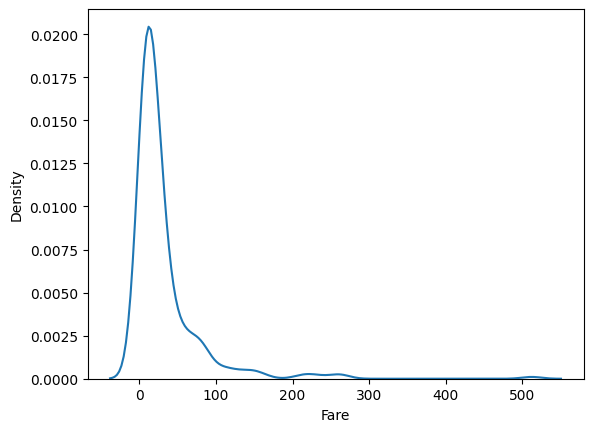

In [6]:
sns.kdeplot(data=df, x="Fare")

From the above graph we can clearly see that the data is left skewed. To handle such skewed dataset we apply `log` transformation.

Fare column after `log` transformation


c:\Users\papsr\anaconda3\envs\dl\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Fare', ylabel='Density'>

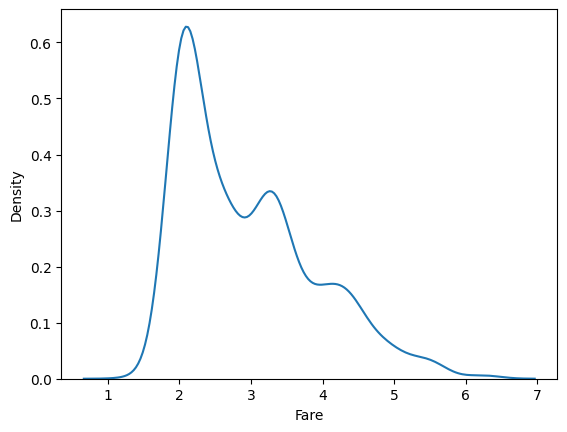

In [8]:
df["Fare"] = np.log(df['Fare'])
print("Fare column after `log` transformation")

sns.kdeplot(data=df, x="Fare")

Based on domain knowledge, it's better to perform feature engineering on columns where data is actually missing.
<br/>
Below is the code to find out which columns has missing data.

In [9]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
IsAlone          0
dtype: int64

We can clearly see that `Cabin` column has the most no. of missing values.
Although we can drop this column but a better solution is to extract the Cabin Deck from the column and fill all the missing value with alphabet `U` which refers to `Unknown`, which shows data is missing in particular column.

In [10]:
print("Missing value in Cabin col (BEFORE) : ", df.Cabin.isna().sum())
df['Cabin'] = df['Cabin'].fillna('U')
print("Missing value in Cabin col (AFTER) : ", df.Cabin.isna().sum())

Missing value in Cabin col (BEFORE) :  687
Missing value in Cabin col (AFTER) :  0


In [13]:
df["CabinDeck"] = df["Cabin"].apply(lambda x: str(x)[0])

Another missing column is `Embarked`, filling this with most frequent value in particular column.

In [14]:
print("Missing value in Embarked col (AFTER) : ", df.Embarked.isna().sum())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("Missing value in Embarked col (AFTER) : ", df.Embarked.isna().sum())

Missing value in Embarked col (AFTER) :  2
Missing value in Embarked col (AFTER) :  0


Age column also has missing values.
<br/>
1. one approch is to fill `Age` column with median values.
2. second best approch is to fill same column value with median of those who has similar `title` in front of their names.

In [20]:
# first find our the title of each person.
df["title"] = df.Name.apply(
    lambda x: str(x.strip().split(",")[1]).strip().split(" ")[0]
)

In [21]:
# perform groupby and calculate median in each groups.
df['Age'] = df.groupby("title")["Age"].transform(
    lambda x: x.fillna(x.median())
)

Another kind of feature engineering techniques includes, encoding of categorical columns and scaling of numerical features.
<br/>
All of these techniques i've already done in previous days notebook, please refer them :)